# Динамический парсинг вакансий с HH.ru с помощью Playwright

In [1]:
# Импорт всех модулей, нужных в проекте
import requests
import pandas as pd
from playwright.async_api import async_playwright
import time
import json
import asyncio
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly

__Общая идея:__ нам нужно реализовать парсинг в два этапа:
1. Зайти на страницу поиска, соответствующей запросу "Аналитик", и спарсить с нее ссылки на вакансии.
2. Заходить на странички этих вакансий и парсить с нее все имеющиеся данные. Этот процесс я ускоряю с помощью asyncio.gather() с 5 агентами-парсерами (иначе это будет оооочень долго, я проверял :)

В Playwright нужно использовать Async API, так как Jupyter Notebook создает и запускает свой asyncio луп. Если бы мы использовали Sync API, то Playwright пытался бы запустить еще один луп, в результате чего произошла бы ошибка. В Async API не создается новый луп, а встраивается в тот, который уже запущен Jupyter, поэтому все окей.

In [2]:
class HHScraper:
    data_items = {"vacancy_card": "[data-qa='vacancy-serp__vacancy']",
    "card_title": "[data-qa='serp-item__title']",
    "title": "[data-qa='vacancy-title']",
    "salary": "[data-qa='vacancy-salary']",
    "experience": "[data-qa='vacancy-experience']",
    "company": "[data-qa='vacancy-company-name']",
    "area": "[data-qa='vacancy-view-location']",
    "employment_type": "[data-qa='common-employment-text']",
    "description": "[data-qa='vacancy-description']",
    "schedule": "[data-qa='work-schedule-by-days-text']",
    "working_hours": "[data-qa='working-hours-text']",
    "hiring_format": "[data-qa='vacancy-hiring-formats']",
    "work_format": "[data-qa='work-formats-text']"}

    def __init__(self, query, pages, workers):
        self.query = query
        self.pages = pages
        self.workers = workers
        self.pages_ok = 0
        self.pages_failed = 0
        self.vacancy_ok = 0
        self.vacancy_failed = 0

    async def run(self):
        async with async_playwright() as p:
            browser = await p.chromium.launch()
            urls = await self.collect_urls(browser)
            results = await self.scrape_details(browser, urls)

        print(f'Страниц загружено: {self.pages_ok}')
        print(f'Страниц не загружено: {self.pages_failed}')
        print(f'Вакансий загружено: {self.vacancy_ok}')
        print(f'Вакансий не загружено: {self.vacancy_failed}')

        return results

    async def collect_urls(self, browser):
        page = await browser.new_page()
        urls = []
        for page_num in range(self.pages):
            url = (f'https://hh.ru/search/vacancy?text={self.query}&search_field=name&page={page_num}&items_on_page=50')
            try:
                await page.goto(url, wait_until='domcontentloaded', timeout=60000)
                await page.wait_for_selector(self.data_items['vacancy_card'], timeout=15000)
                self.pages_ok += 1
            except Exception:
                self.pages_failed += 1
                continue
            cards = await page.query_selector_all(self.data_items['vacancy_card'])
            for card in cards:
                title_el = await card.query_selector(self.data_items['card_title'])
                if title_el:
                    urls.append(await title_el.get_attribute('href'))
        await page.close()
        return urls

    async def scrape_details(self, browser, urls):
        worker_pages = [await browser.new_page() for _ in range(self.workers)]
        chunk_size = len(urls) // self.workers + 1
        chunks = [urls[i:i + chunk_size] for i in range(0, len(urls), chunk_size)]
        all_results = await asyncio.gather(*[self.worker(worker_pages[i], chunks[i]) for i in range(len(chunks))])
        for worker_page in worker_pages:
            await worker_page.close()
        return [item for sublist in all_results for item in sublist]

    async def worker(self, page, chunk):
        results = []
        for url in chunk:
            details = await self.get_vacancy_details(page, url)
            if details:
                self.vacancy_ok += 1
                results.append(details)
            else:
                self.vacancy_failed += 1
        return results

    async def get_text(self, page, selector):
        el = await page.query_selector(selector)
        return await el.inner_text() if el else None
        
    async def get_vacancy_details(self, page, url):
        try:
            await page.goto(url, wait_until='domcontentloaded', timeout=60000)
            await page.wait_for_selector(self.data_items['title'], timeout=15000)

            return {'url': url,
        'title': await self.get_text(page, self.data_items['title']),
        'salary': await self.get_text(page, self.data_items['salary']),
        'experience': await self.get_text(page, self.data_items['experience']),
        'company': await self.get_text(page, self.data_items['company']),
        'area': await self.get_text(page, self.data_items['area']),
        'schedule': await self.get_text(page, self.data_items['schedule']),
        'working_hours': await self.get_text(page, self.data_items['working_hours']),
        'hiring_format': await self.get_text(page, self.data_items['hiring_format']),
        'work_format': await self.get_text(page, self.data_items['work_format']),
        'employment_type': await self.get_text(page, self.data_items['employment_type']),
        'description': await self.get_text(page, self.data_items['description'])}

        except Exception:
            return {}

scraper = HHScraper(query='Аналитик', pages=40, workers=5)
data = await scraper.run()

Страниц загружено: 40
Страниц не загружено: 0
Вакансий загружено: 752
Вакансий не загружено: 48


(В идеале, конечно, было бы логировать причины, почему вакансии не загрузились. Я это делал, во всех случаях это таймаут, в финальной версии убрал логирование, чтобы не засорять ноутбук. Увеличивать таймаут тоже не очень хочется с учетом того, что и так собрано достаточное кол-во вакансий, а ячейка и так не очень быстро исполняется.)

In [89]:
df = pd.DataFrame(data)

In [90]:
df.head()

,url,title,salary,experience,company,area,schedule,working_hours,hiring_format,work_format,employment_type,description
0,https://hh.ru/vacancy/133409608?query=%D0%90%D...,Системный/бизнес-аналитик,None,не требуется,ТОО Комита Цифровые Технологии,None,График: 5/2,Рабочие часы: 8,Оформление: Трудовой договор,Формат работы: гибрид,Полная занятость,Комита Цифровые Технологии (группа компаний Ко...
1,https://hh.ru/vacancy/133307660?query=%D0%90%D...,MarTech Engineer / Специалист по веб-аналитике...,"130 000 ₽ за месяц, на руки",3–6 лет,ИП КРИВОШЕЙ ВАДИМ ПЕТРОВИЧ,None,График: 5/2,Рабочие часы: 8,None,Формат работы: удалённо,Полная занятость,Наша маркетинг-команда генерирует много трафик...
2,https://hh.ru/vacancy/132276822?query=%D0%90%D...,Junior Data Analyst,None,не требуется,ТОО Мобайл Телеком-Сервис (Объединенная Компан...,None,График: 5/2,Рабочие часы: 8,None,Формат работы: на месте работодателя или гибрид,Полная занятость,"Мы верим, что новое качество жизни можно нести..."
3,https://hh.ru/vacancy/133268928?query=%D0%90%D...,Стажер-аналитик,None,не требуется,СП ООО Nazarov Rakhimbayev Group,None,None,None,None,Формат работы: на месте работодателя,Полная занятость\nСтажировка,Обязанности:\nИзучение и анализ информации на ...
4,https://hh.ru/vacancy/133352863?query=%D0%90%D...,Системный аналитик,"от 200 000 ₽ за месяц, на руки",1–3 года,ООО ВБЦ,None,График: 5/2,Рабочие часы: 8,None,Формат работы: на месте работодателя или гибрид,Полная занятость,"Мы — финтех-компания с ИТ аккредитацией, работ..."


Проверим на наличие дубликатов:

In [94]:
df.duplicated(subset=['url']).sum()

np.int64(0)

In [95]:
df.to_csv('hh_dataset.csv')

## Предобработка данных

### Рабочие часы, график, формат оформления, работы и тип занятости

In [61]:
df['working_hours'] = pd.to_numeric(df['working_hours'].str.split(': ').str[1], errors='coerce')
df['schedule'] = df['schedule'].str.split(': ').str[1]
df['hiring_format'] = df['hiring_format'].str.split(': ').str[1]
df['work_format'] = df['work_format'].str.split(': ').str[1]

### Нормализация зарплат

In [6]:
df['salary'].head(20)

0                                                  None
1                           130 000 ₽ за месяц, на руки
2                                                  None
3                                                  None
4                        от 200 000 ₽ за месяц, на руки
5                                                  None
6              от 89 000 до 120 000 ₽ за месяц, на руки
7              до 250 000 ₽ за месяц, до вычета налогов
8                 от 3 000 до 5 000 $ за месяц, на руки
9                        от 120 000 ₽ за месяц, на руки
10                                                 None
11             до 150 000 ₽ за месяц, до вычета налогов
12                                                 None
13                                                 None
14                                                 None
15    от 250 000 до 350 000 ₽ за месяц, до вычета на...
16              от 85 000 ₸ за месяц, до вычета налогов
17                                              

На HH зарплаты могут быть в множестве разных форматов: только с нижней границей (от Х рублей), только с верхней границей (до Y рублей), диапазон (X-Y рублей), точная зарплата (Х рублей), и при этом может указываться как зарплата до вычета налогов, так и после вычета ("на руки"). Я решил преобразовать все эти данные в 2 признака: salary_upper и salary_lower, которые отражают зарплату после вычета налогов. Если указана зарплата до вычета, то я отнимаю 13% НДФЛ (конечно, на какие-то зарплаты налог другой, но это в любом случае хорошая аппроксимация). Кроме того, в некоторых вакансиях зарплаты указаны не в рублях. В таком случае я преобразую их в рубли по курсу, актуальному на 16 мая 2026.

In [62]:
def salary_type(salary_str):
    if not salary_str:
        return None
    elif 'до вычета налогов' in salary_str.lower():
        return 'до вычета налогов'
    elif 'на руки' in salary_str.lower():
        return 'на руки'
    return None

df['salary_type'] = df['salary'].apply(salary_type)

In [63]:
def salary_currency(salary_str):
    if not salary_str:
        return None
    currency_map = {'₽': 'Рубль',
        "so'm": 'Узбекский сом',
        'Br': 'Белорусский рубль',
        '€': 'Евро',
        '$': 'Доллар',
        '₸': 'Тенге',
        'сом': 'Киргизский сом'}
    for symbol, currency in currency_map.items():
        if symbol in salary_str:
            return currency
    return None

df['salary_currency'] = df['salary'].apply(salary_currency)
convertation_map = {'Киргизский сом': 0.83, 'Белорусский рубль': 26.14, 'Евро': 84.6, 'Доллар': 72.76, 'Тенге': 0.15, 'Рубль': 1, 'Узбекский сом': 0.006}

def salary_bounds_converted(row):
    salary_str = row['salary']
    if not salary_str:
        return pd.Series([None, None])
    salary_str = salary_str.replace('\xa0', ' ')
    salary_str = salary_str.lower()
    salary_str = re.sub(r'(?<=\d)\s(?=\d)', '', salary_str)
    salary_lst = [x for x in salary_str.split(' ') if x]
    salary_from = None
    salary_to = None
    
    if 'от' in salary_lst and ('до' in salary_lst and salary_lst[salary_lst.index('до') + 1].isdigit()):
        salary_from = int(salary_lst[salary_lst.index('от') + 1])
        salary_to = int(salary_lst[salary_lst.index('до') + 1])
    elif 'от' in salary_lst:
        salary_from = int(salary_lst[salary_lst.index('от') + 1])
    elif 'до' in salary_lst and salary_lst[salary_lst.index('до') + 1].isdigit():
        salary_to = int(salary_lst[salary_lst.index('до') + 1])
    else:
        if salary_lst[0].isdigit():
            salary_from = salary_to = int(salary_lst[0])
        
    rate = convertation_map.get(row['salary_currency'])
    if rate is None:
        return pd.Series([None, None])
    salary_from = round(salary_from * rate) if salary_from is not None else None
    salary_to = round(salary_to * rate) if salary_to is not None else None
    if row['salary_type'] == 'до вычета налогов':
        salary_from = round(salary_from * 0.87) if salary_from else None
        salary_to = round(salary_to * 0.87) if salary_to else None
    return pd.Series([salary_from, salary_to])

df[['salary_from', 'salary_to']] = df.apply(salary_bounds_converted, axis=1)

### Извлечение типа аналитики

Я разделяю следующие типы аналитиков:
1. Бизнес-аналитик
2. Финансовый аналитик
3. Системный аналитик
4. Риск-аналитик
5. Аналитик данных/Data Analyst
6. Инвестиционный аналитик
7. Аналитик 1С
8. Supply Chain аналитик
9. Продуктовый аналитик
10. Экономист-аналитик
11. BI аналитик
12. Маркетолог-аналитик/маркетинговый аналитик

Опять-таки эта классификация не является идеальной, но должна извлекать большинство вакансий. 

In [99]:
analyst_patterns = {
    'Бизнес-аналитик': r'бизнес.?аналитик',
    'Финансовый аналитик': r'финансов\w+\s+аналитик|аналитик\s+финансов',
    'Системный аналитик': r'системн\w+\s+аналитик|аналитик\s+системн',
    'Аналитик данных/Data Analyst': r'аналитик\s+данных|data\s+analyst',
    'Инвестиционный аналитик': r'инвестицион\w+\s+аналитик|аналитик\s+инвестиц',
    'Аналитик 1С': r'аналитик\s+1с|1с.?аналитик',
    'Supply Chain аналитик': r'supply\s*chain\s+аналитик|аналитик\s+supply\s*chain',
    'Продуктовый аналитик': r'продуктов\w+\s+аналитик|product\s+analyst|аналитик\s+продукт',
    'Экономист-аналитик': r'экономист.?аналитик|аналитик.?экономист',
    'BI аналитик': r'\bbi\b.{0,5}аналитик|аналитик.{0,5}\bbi\b',
    'Маркетолог-аналитик/маркетинговый аналитик': r'маркетолог.?аналитик|маркетингов\w+\s+аналитик|аналитик\s+маркетинг',
    'Риск-аналитик': r'риск.?аналитик|аналитик\s+риск',
}

def get_analyst_types(title):
    if not title or pd.isna(title):
        return set()
    t = title.lower()
    result = set()
    for analyst_type, pattern in analyst_patterns.items():
        if re.search(pattern, t):
            result.add(analyst_type)
    return result

df['analyst_type'] = df['title'].apply(get_analyst_types)

### Извлечение навыков

#### Построение списка навыков

Сначала нужно построить список из тех навыков, которые мы будем искать в тексте. Для этого я собрал список из 1000 наиболее популярных n-граммы (1 <= n <= 5), отсмотрел его и выбрал наиболее популярные навыки

In [65]:
from sklearn.feature_extraction.text import CountVectorizer

stop_words = ['и', 'в', 'на', 'с', 'по', 'для', 'от', 'до', 'из', 'или', 'а', 'но', 'не', 'что', 'как', 'так', 'при', 
              'за', 'к', 'о', 'об', 'это', 'вы', 'мы', 'вас', 'нас', 'опыт', 'работы', 'данных', 'знание', 'понимание', 'умение',
              'навыки', 'владение', 'требований', 'требования', 'обязанности', 'участие', 'подготовка', 'условия', 'возможность', 'предлагаем',
              'график', 'офис', 'формат', 'образование', 'высшее', 'оформление', 'компании', 'компания', 'команде', 'команды', 'команда', 'лет',
              'дмс', 'тк', 'рф', 'тк рф', 'ищем', 'будет', 'будет плюсом', 'плюсом', 'предстоит', 'заниматься', 'также', 'более', 'их', 'со', 'чем']

texts = df['description'].dropna().tolist()

vectorizer = CountVectorizer(ngram_range=(1, 5), stop_words=stop_words)
matrix = vectorizer.fit_transform(texts)
counts = matrix.sum(axis=0).A1
ngrams = vectorizer.get_feature_names_out()

top_ngrams = pd.DataFrame({'ngram': ngrams, 'count': counts})
top_ngrams = top_ngrams.sort_values('count', ascending=False)
top_ngrams = top_ngrams.head(1000).reset_index(drop=True)

top_ngrams.to_csv('top_ngrams.csv', index=False, encoding='utf-8-sig')

__Список навыков__:
1. Языки программирования: Python (Pandas, Numpy), R, Scala, Java, Bash
2. Базы и хранилища данных: DWH, SQL (PostgreSQL, MySQL, SQLite, Oracle)
3. Визуализация и BI: Power BI, Tableau
4. Data Engineering: Spark, Hadoop, Kafka, Airflow, Rabbitmq
5. Таблицы: Excel, Google Sheets, сводные таблицы, power query
6. Управление проектами: Jira, Miro, Scrum, Kanban
7. Документация и контроль версий: Github, Confluence, Notion
8. Статистика и математика: Статистика, теория вероятности, A/B тесты, регрессионный анализ, временные ряды
9. Машинное обучение: SkLearn, PyTorch
10. Моделирование бизнес-процессов: BPMN, UML, нотация
11. Работа с API: REST, SOAP, Swagger/OpenAPI
12. Продукт: знание продуктовых метрик, user stories, use cases
13. Soft skills: аналитический склад ума/аналитическое мышление, системное мышление, внимательность/внимание деталям, грамотная устная/письменная речь
14. Использование ИИ-инструментов: ChatGPT, Claude (Claude Code), Gemini, Copilot
15. Бизнес-системы: CRM, 1C

Некоторые навыки являются поднавыками других навыков: например, Pandas являются поднавыком Python. В таком случае, если в тексте присутствуют Pandas, то засчитывается также и навык Python. Эта классификация, конечно, не является идеальной и исчерпывающей, но будем надеяться, что она достаточно хороша, чтобы извлекать большую часть важных для аналитика навыков.

In [66]:
skills_tree = {
    "Языки программирования": {
        "Python": ["Pandas", "NumPy"],
        "R": [],
        "Scala": [],
        "Java": [],
        "Bash": [],
    },
    "Базы и хранилища данных": {
        "DWH": [],
        "SQL": ["PostgreSQL", "MySQL", "SQLite", "Oracle"],
    },
    "Data Engineering": {
        "Spark": [],
        "Hadoop": [],
        "Kafka": [],
        "Airflow": [],
        "RabbitMQ": [],
    },
    "Машинное обучение": {
        "sklearn": [],
        "PyTorch": [],
    },
    "Интеграция данных": {
        "REST": [],
        "SOAP": [],
        "OpenAPI / Swagger": [],
    },
    "Статистика и математика": {
        "Теория вероятности": [],
        "Математическая статистика": [],
        "A/B тесты": [],
        "Регрессионный анализ": [],
        "Временные ряды": [],
    },
    "Визуализация и BI": {
        "Power BI": [],
        "Tableau": [],
    },
    "Таблицы": {
        "Excel": [],
        "Google Sheets": [],
        "Сводные таблицы": [],
        "Power Query": [],
    },
    "Продукт": {
        "Продуктовые метрики": [],
        "User stories": [],
        "Use cases": [],
    },
    "Моделирование бизнес-процессов": {
        "BPMN": [],
        "UML": [],
    },
    "Бизнес-системы": {
        "CRM": [],
        "1C": [],
    },
    "Управление проектами": {
        "Jira": [],
        "Miro": [],
        "Scrum": [],
        "Kanban": [],
    },
    "Документация и контроль версий": {
        "GitHub": [],
        "Confluence": [],
        "Notion": [],
    },
    "ИИ-инструменты": {
        "ChatGPT": [],
        "Claude": [],
        "Gemini": [],
        "Copilot": [],
    },
    "Soft skills": {
        "Аналитическое мышление": [],
        "Системное мышление": [],
        "Внимательность к деталям": [],
        "Грамотная речь": [],
    },
}

### Поиск с помощью регулярных выражений

Попробуем теперь извлечь навыки из описания вакансии с помощью регулярных выражений. Плюсами этого метода является его прямолинейность, а минусами - трата огромного количества времени на реализацию регулярных выражений и риск того, что не все навыки будут найдены с помощью регулярных выражений.

In [67]:
reg_expressions = {
    "R": r"\bR\b",
    "SQL": r"\bSQL\b",
    "REST": r"\bREST(?:ful)?\b",
    "SOAP": r"\bSOAP\b",
    "OpenAPI / Swagger": r"\b(?:OpenAPI|Swagger)\b",
    "sklearn": r"\b(?:sklearn|scikit[-\s]learn)\b",
    "1C": r"(?<!\w)1[СCс](?!\w)",
    "A/B тесты": r"A/B[\s\-]?тест\w*",
    "Power BI": r"\bPower\s+BI\b",
    "Power Query": r"\bPower\s+Query\b",
    "Google Sheets": r"\bGoogle\s+Sheets\b",
    "RabbitMQ": r"\bRabbit\s*MQ\b",
    "ChatGPT": r"\bChat\s*GPT\b",
    "Сводные таблицы": r"сводн\w+\s+таблиц\w*",
    "Теория вероятности": r"теори\w+\s+вероятност\w*",
    "Математическая статистика": r"математическ\w+\s+статистик\w*",
    "Регрессионный анализ": r"регрессионн\w+\s+анализ\w*",
    "Временные ряды": r"временн\w+\s+ряд\w*",
    "Продуктовые метрики": r"продуктов\w+\s+метрик\w*",
    "Аналитическое мышление": r"аналитическ\w+\s+мышлени\w*",
    "Системное мышление": r"системн\w+\s+мышлени\w*",
    "Внимательность к деталям": r"внимательност\w+\s+к\s+деталям",
    "Грамотная речь": r"грамотн\w+\s+реч\w*",
    "User stories": r"\buser\s+stor(?:y|ies)\b",
    "Use cases": r"\buse\s+cases?\b",
}

In [68]:
def build_index(skills_tree):
    patterns = {}
    parent = {}
    for category, skills in skills_tree.items():
        patterns[category] = re.compile(reg_expressions.get(category, rf'(?<!\w){re.escape(category)}(?!\w)'), re.IGNORECASE)
        for skill, sub_skills in skills.items():
            patterns[skill] = re.compile(reg_expressions.get(skill, rf'(?<!\w){re.escape(skill)}(?!\w)'), re.IGNORECASE)
            parent[skill] = category
            for sub in sub_skills:
                patterns[sub] = re.compile(reg_expressions.get(sub, rf'(?<!\w){re.escape(sub)}(?!\w)'), re.IGNORECASE)
                parent[sub] = skill
    return patterns, parent

def extract_skills(text, patterns, parent):
    matched = set()
    for name, pattern in patterns.items():
        if pattern.search(text):
            matched.add(name)
            node = name
            while node in parent:
                node = parent[node]
                matched.add(node)
    return matched

In [69]:
patterns, parent = build_index(skills_tree)
df['skills_manual'] = df['description'].apply(lambda text: extract_skills(text, patterns, parent))

Ручной анализ нескольких вакансий показывает, что в целом почти все скиллы удается извлечь с помощью регулярных выражений.

# Анализ

### Очистка выбросов

Очищаем данные по зарплате с помощью стандартного метода межквартильного размаха.

In [70]:
def remove_outliers(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return df[((df[column] >= lower) & (df[column] <= upper)) | df[column].isna()]

df = remove_outliers(df, 'salary_from')
df = remove_outliers(df, 'salary_to')

### Общая описательная статистика переменных

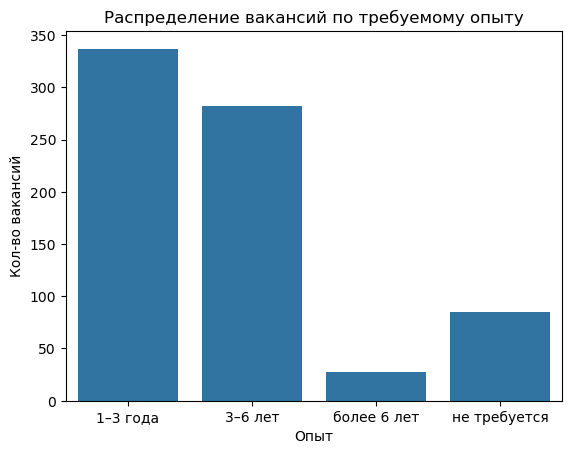

In [71]:
gr_exp = df.groupby('experience').agg({'url': 'count'}).reset_index()
ax = sns.barplot(gr_exp, x = 'experience', y = 'url')
ax.set(xlabel = 'Опыт', ylabel = 'Кол-во вакансий', title = 'Распределение вакансий по требуемому опыту')
plt.show()

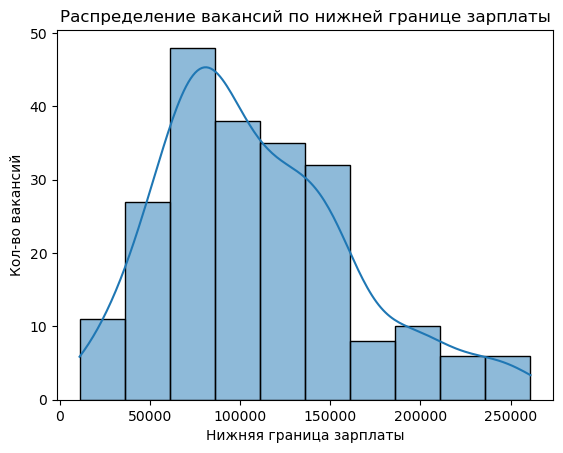

In [18]:
ax = sns.histplot(df, x='salary_from', kde=True)
ax.set(xlabel = 'Нижняя граница зарплаты', ylabel = 'Кол-во вакансий', title = 'Распределение вакансий по нижней границе зарплаты')
plt.show()

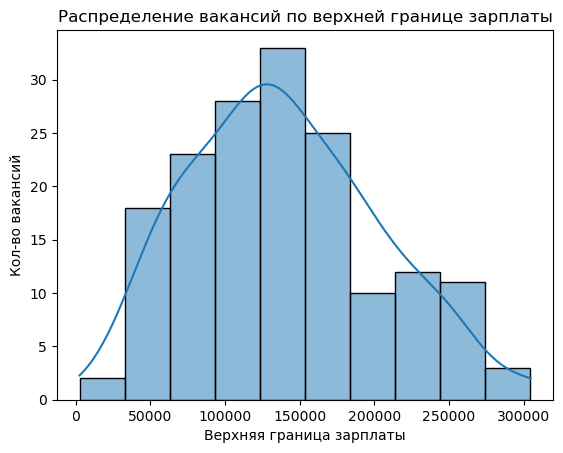

In [19]:
ax = sns.histplot(df, x='salary_to', kde=True)
ax.set(xlabel = 'Верхняя граница зарплаты', ylabel = 'Кол-во вакансий', title = 'Распределение вакансий по верхней границе зарплаты')
plt.show()

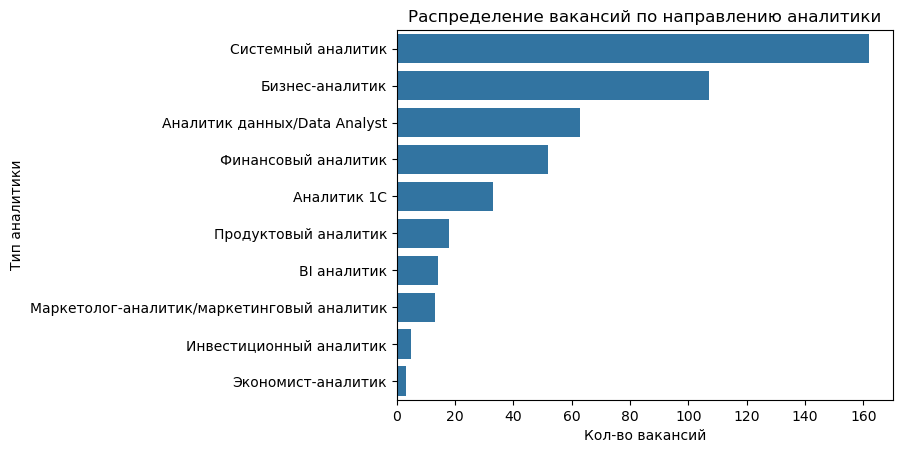

In [100]:
analyst_type_counts = df['analyst_type'].explode().value_counts().reset_index()
analyst_type_counts.columns = ['analyst_type', 'vacancy_count']
ax = sns.barplot(analyst_type_counts, x = 'vacancy_count', y = 'analyst_type')
ax.set(xlabel = 'Кол-во вакансий', ylabel = 'Тип аналитики', title = 'Распределение вакансий по направлению аналитики')
plt.show()

### Популярность навыков

In [73]:
skill_counts = df['skills_manual'].explode().value_counts().reset_index()
skill_counts.columns = ['skill', 'vacancy_count']

In [74]:
# Верхнеуровневые навыки
upper_level_skills = skills_tree.keys()
df_upper = skill_counts[skill_counts['skill'].isin(upper_level_skills)]
# Нижнеуровневые навыки
df_lower = skill_counts[~skill_counts['skill'].isin(upper_level_skills)]
top_20 = df_lower.nlargest(20, 'vacancy_count')

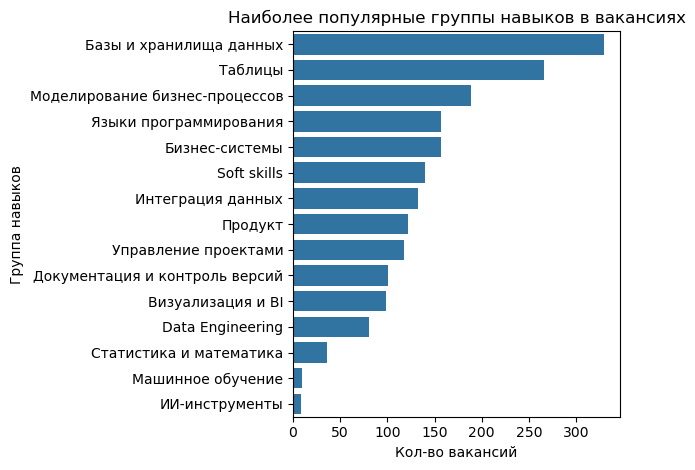

In [75]:
sns.barplot(data=df_upper, x='vacancy_count', y='skill')
plt.title('Наиболее популярные группы навыков в вакансиях')
plt.xlabel('Кол-во вакансий')
plt.ylabel('Группа навыков')
plt.tight_layout()
plt.show()

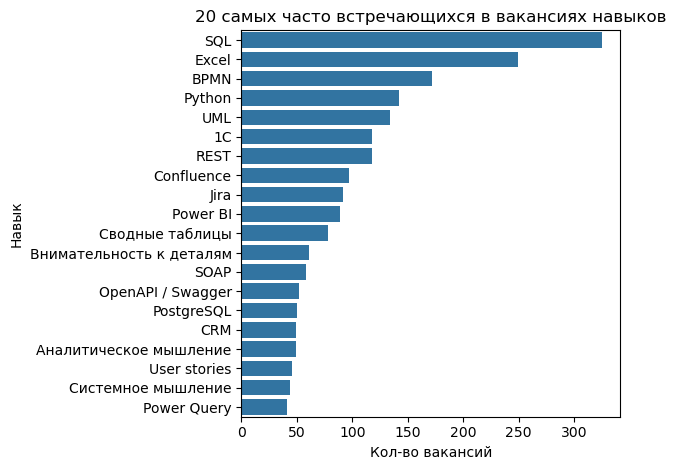

In [26]:
sns.barplot(data=top_20, x='vacancy_count', y='skill')
plt.title('20 самых часто встречающихся в вакансиях навыков')
plt.xlabel('Кол-во вакансий')
plt.ylabel('Навык')
plt.tight_layout()
plt.show()

### Популярность навыков в разрезе опыта

In [76]:
no_exp = df[df['experience'] == 'не требуется']
small_exp = df[df['experience'] == '1–3 года']
medium_exp = df[df['experience'] == '3–6 лет']
large_exp = df[df['experience'] == 'более 6 лет']

In [77]:
no_exp_counts = no_exp['skills_manual'].explode().value_counts()
small_exp_counts = small_exp['skills_manual'].explode().value_counts()
medium_exp_counts = medium_exp['skills_manual'].explode().value_counts()
large_exp_counts = large_exp['skills_manual'].explode().value_counts()

In [78]:
skills_by_exp = pd.DataFrame({'no_exp': no_exp_counts,
    'small_exp': small_exp_counts,
    'medium_exp': medium_exp_counts,
    'large_exp': large_exp_counts}).fillna(0).astype(int)

skills_by_exp = skills_by_exp[~skills_by_exp.index.isin(upper_level_skills)]

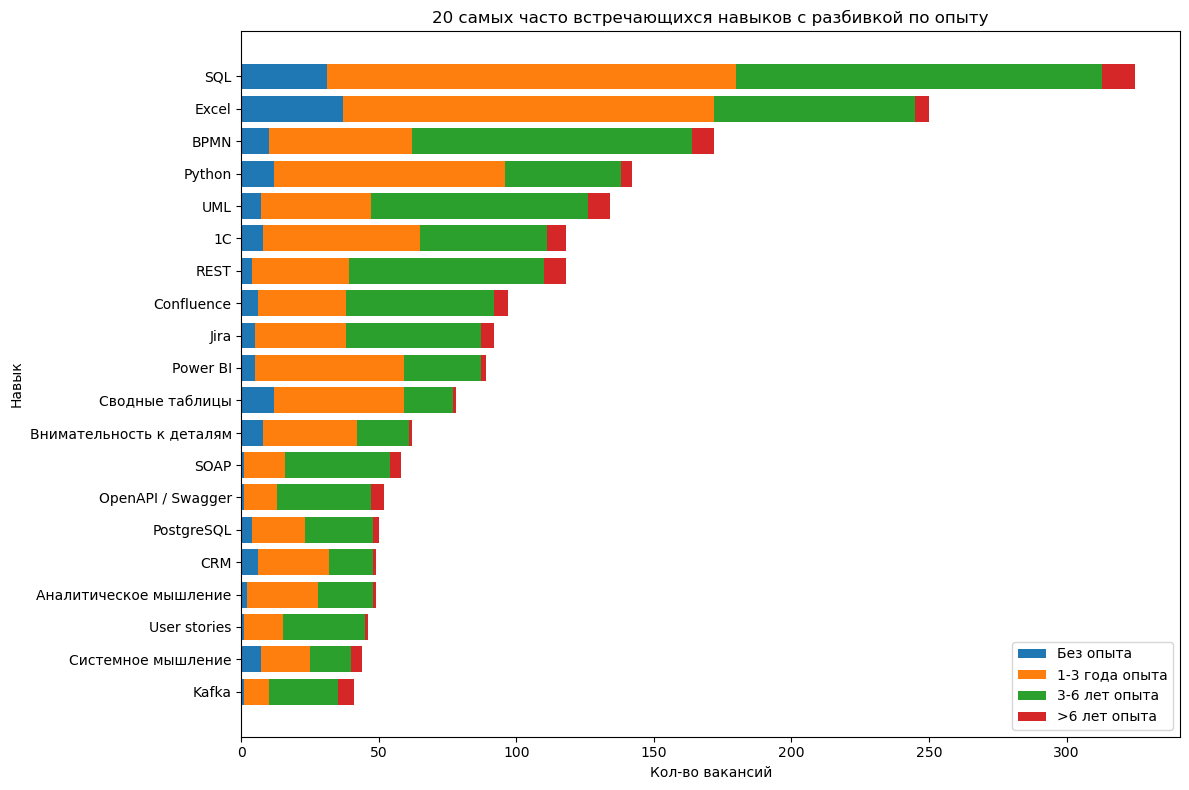

In [79]:
df_plot = skills_by_exp.assign(total=skills_by_exp.sum(axis=1)).nlargest(20, 'total').sort_values('total').drop(columns='total')

fig, ax = plt.subplots(figsize=(12, 8))
left = pd.Series([0] * len(df_plot), index=df_plot.index)
cols = ['no_exp', 'small_exp', 'medium_exp', 'large_exp']
labels = ['Без опыта', '1-3 года опыта', '3-6 лет опыта', '>6 лет опыта']
for col, label in zip(cols, labels):
    ax.barh(df_plot.index, df_plot[col], left=left, label=label)
    left += df_plot[col]

ax.set_title('20 самых часто встречающихся навыков с разбивкой по опыту')
ax.set_xlabel('Кол-во вакансий')
ax.set_ylabel('Навык')
ax.legend()
plt.tight_layout()
plt.show()

Можно заметить, что:
1. На вакансиях без опыта Эксель более важен чем SQL, в отличие от вакансий с опытом, что довольно логично, учитывая, что Эксель является более распространенным инструментом, который даже в школе учат.
2. Также на вакансиях без опыта значительно реже спрашивают BPMN и UML, а вот на вакансиях условных "джунов" и "мидлов" он становится более актуальным.

### Популярность навыков в разрезе типов аналитики

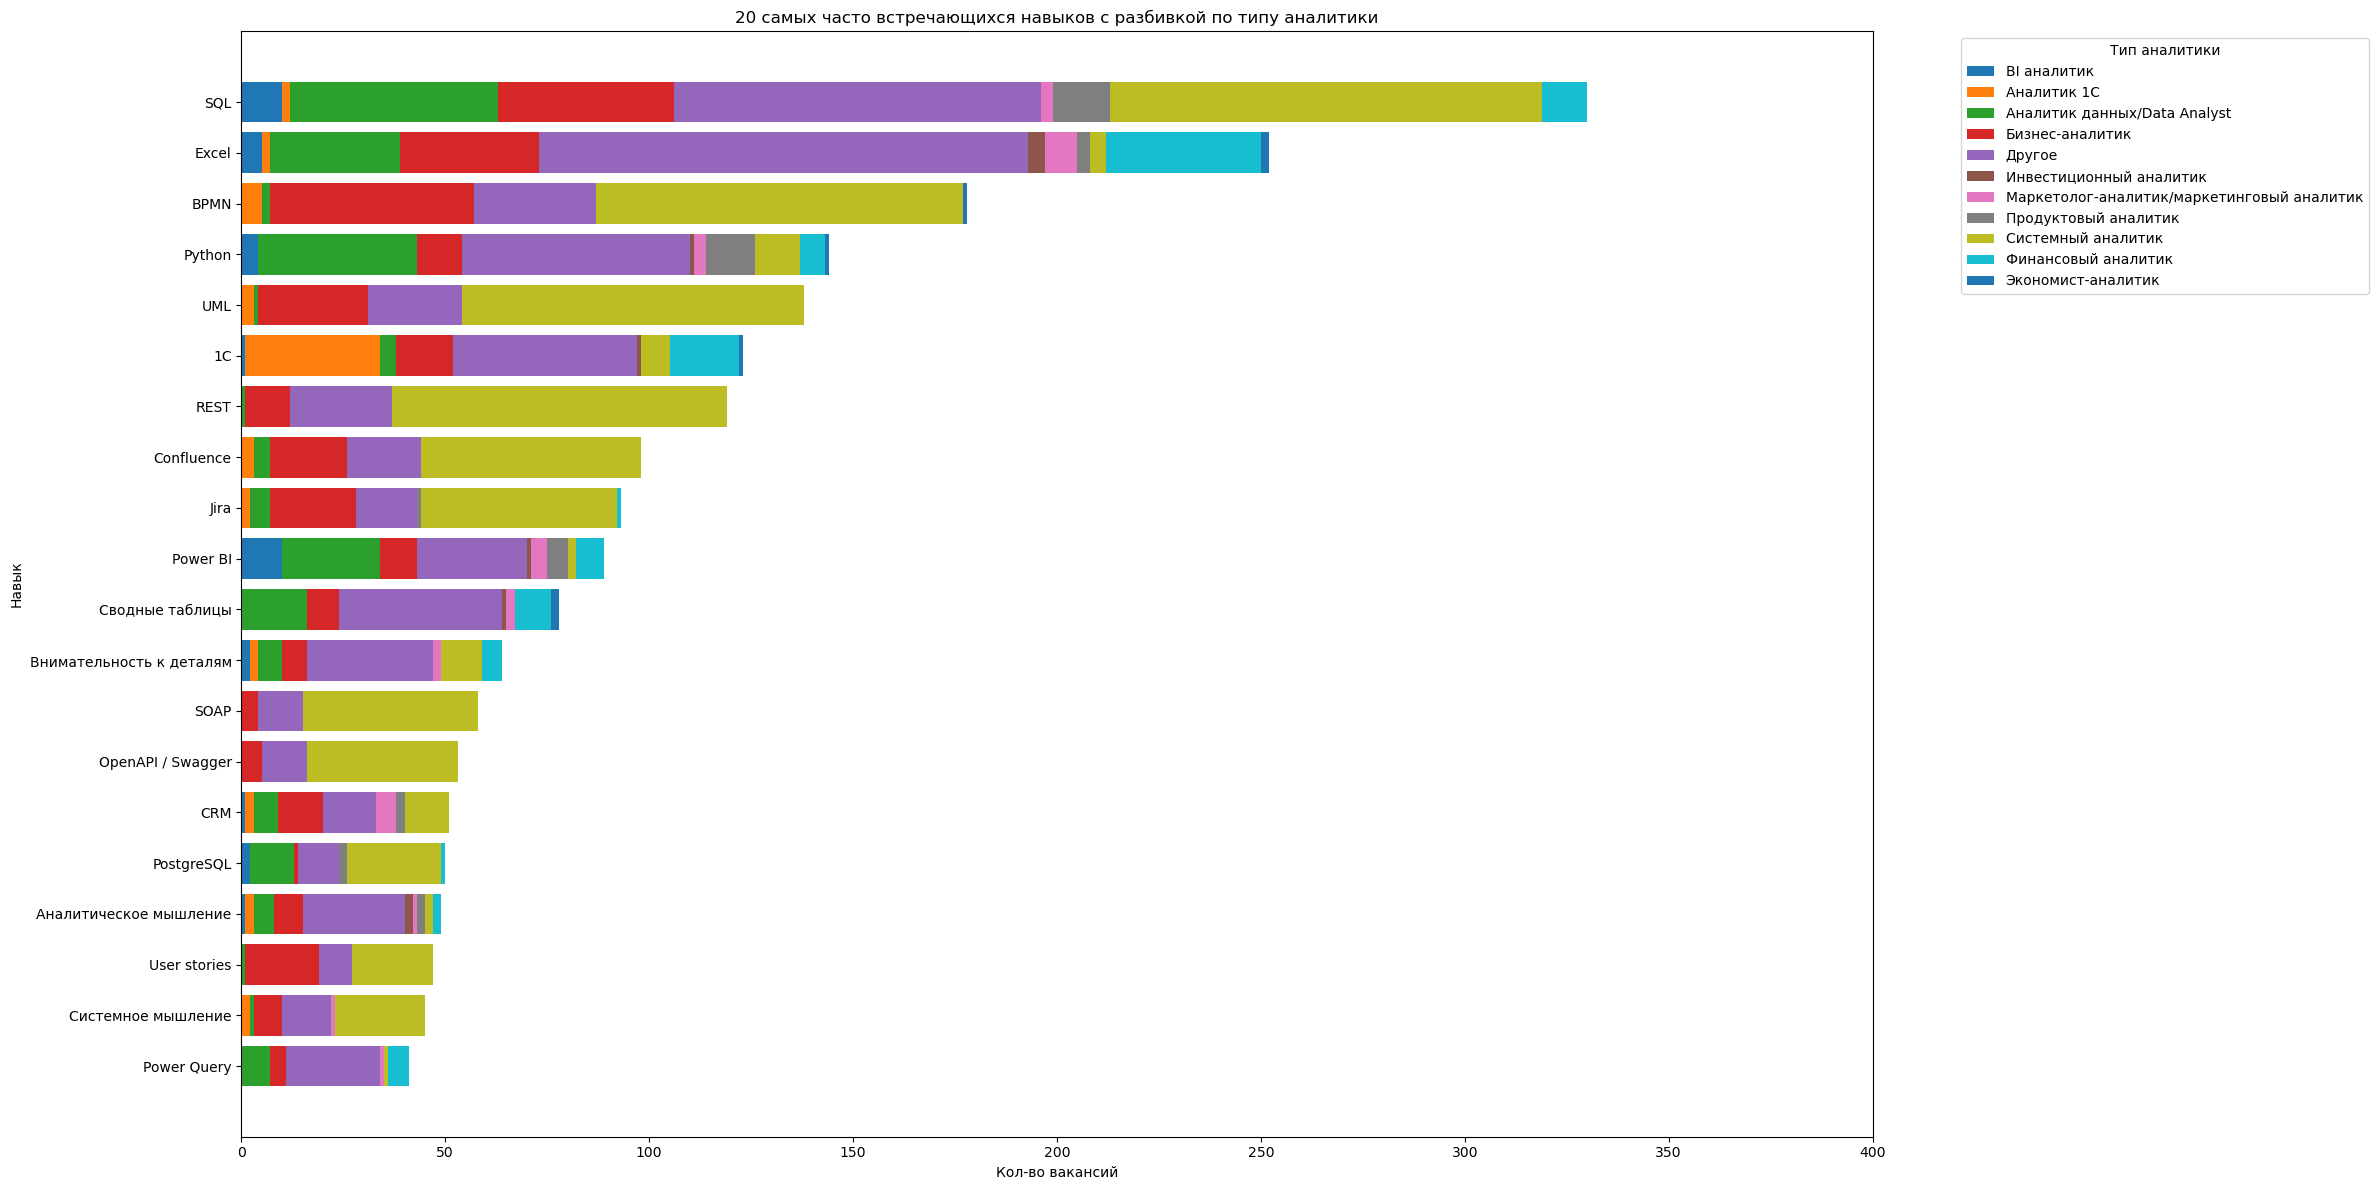

In [80]:
types_df = df.explode('skills_manual')
types_df = types_df[~types_df['skills_manual'].isin(upper_level_skills)]
types_df = types_df.explode('analyst_type')
types_df['analyst_type'] = types_df['analyst_type'].fillna('Другое')
pivot_full = types_df.groupby(['skills_manual', 'analyst_type']).size().unstack(fill_value=0)
pivot = pivot_full.loc[pivot_full.sum(axis=1).sort_values(ascending=True).tail(20).index]

fig, ax = plt.subplots(figsize=(24, 12))
left = pd.Series([0] * len(pivot), index=pivot.index)

for col in pivot.columns:
    ax.barh(pivot.index, pivot[col], left=left, label=col)
    left += pivot[col]

ax.set_title('20 самых часто встречающихся навыков с разбивкой по типу аналитики')
ax.set_xlabel('Кол-во вакансий')
ax.set_ylabel('Навык')
ax.legend(title='Тип аналитики', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlim(0, max(400, left.max()))
plt.tight_layout()
plt.show()

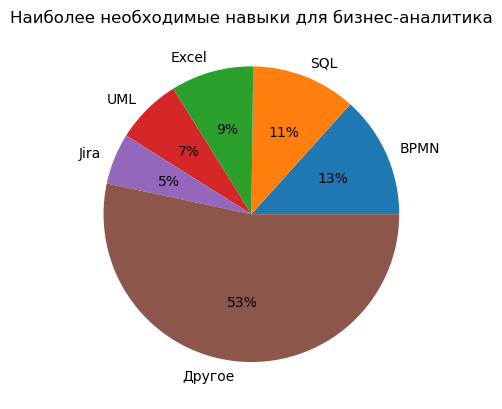

In [93]:
def create_pie_chart(analyst_type, pivot_full=pivot_full):
    column = pivot_full[analyst_type]
    total = column.sum()
    top5 = column.nlargest(5)
    other = int(total - top5.sum())
    sizes = top5.tolist() + [other]
    labels = top5.index.tolist() + ['Другое']
    return sizes, labels

sizes_1, labels_1 = create_pie_chart('Бизнес-аналитик')
plt.pie(sizes_1, labels=labels_1, autopct='%d%%')
plt.title('Наиболее необходимые навыки для бизнес-аналитика')
plt.show()

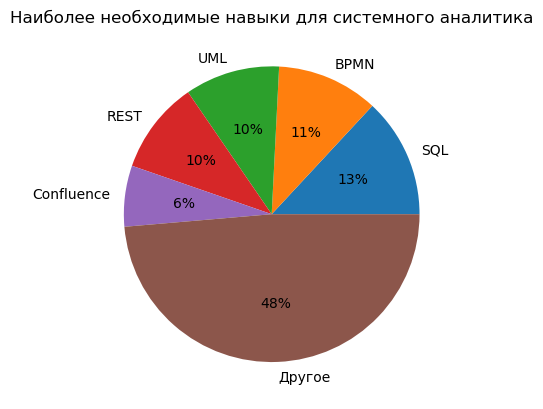

In [82]:
sizes_2, labels_2 = create_pie_chart('Системный аналитик')
plt.pie(sizes_2, labels=labels_2, autopct='%d%%')
plt.title('Наиболее необходимые навыки для системного аналитика')
plt.show()

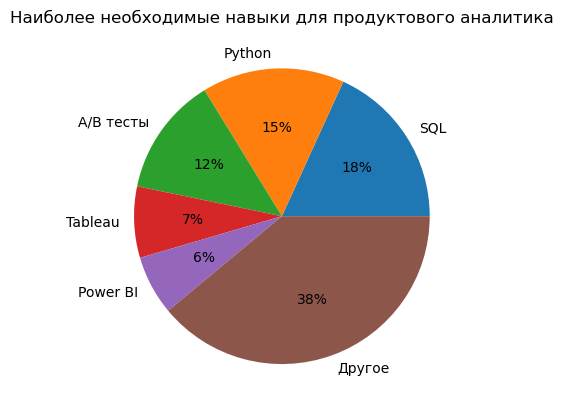

In [83]:
sizes_3, labels_3 = create_pie_chart('Продуктовый аналитик')
plt.pie(sizes_3, labels=labels_3, autopct='%d%%')
plt.title('Наиболее необходимые навыки для продуктового аналитика')
plt.show()

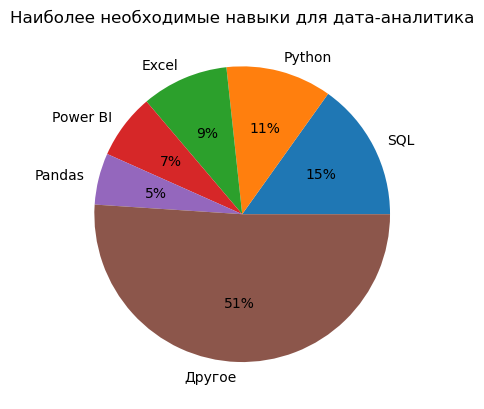

In [92]:
sizes_4, labels_4 = create_pie_chart('Аналитик данных/Data Analyst')
plt.pie(sizes_4, labels=labels_4, autopct='%d%%')
plt.title('Наиболее необходимые навыки для дата-аналитика')
plt.show()

Выводы о стеках технологий для различных типов аналитики:

- Системный аналитик - SQL, BPMN, UML, REST, Confluence, Jira, SOAP
- Аналитик данных - SQL, Excel, Python, Power BI, сводные таблицы
- Бизнес-аналитик - BPMN, SQL, Excel, UML, Jira, 1C
- BI-аналитик - Power BI, SQL, Excel, Python
- 1C-аналитик - 1С))
- Продуктовый аналитик - Sql, Python, Power BI, Excel